In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/GOOG.csv")

In [3]:
# Convert
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

news_df = news_df.dropna(subset=['date'])

In [4]:
#Filter ofr news 
goog_news = news_df[news_df['stock'] == 'GOOG'].copy()

In [5]:
#create daily filed
goog_news['date_only'] = goog_news['date'].dt.date
stock_df['date_only'] = stock_df['Date'].dt.date

In [6]:
sia = SentimentIntensityAnalyzer()

goog_news['sentiment'] = goog_news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [7]:
goog_news['date_only'] = goog_news['date'].dt.date

daily_sentiment = goog_news.groupby('date_only')['sentiment'].mean().reset_index()

In [8]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['Date'].dt.date

stock_df = stock_df.sort_values('date_only')
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

In [9]:
#Aggregate daily senitment
daily_sentiment = (
    goog_news
    .groupby('date_only')['sentiment']
    .mean()
    .reset_index()
)

In [10]:
#Merge dataset
merged_df = pd.merge(
    stock_df[['date_only', 'daily_return']],
    daily_sentiment,
    on='date_only',
    how='left'
)
merged_df['sentiment'] = merged_df['sentiment'].fillna(0)
merged_df = merged_df.dropna(subset=['daily_return'])

In [11]:
# Check merged data
print("Shape:", merged_df.shape)

Shape: (3773, 3)


In [12]:
#Pearson correlation
correlation, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: -0.003734414125750664
P-value: 0.8186277882015552


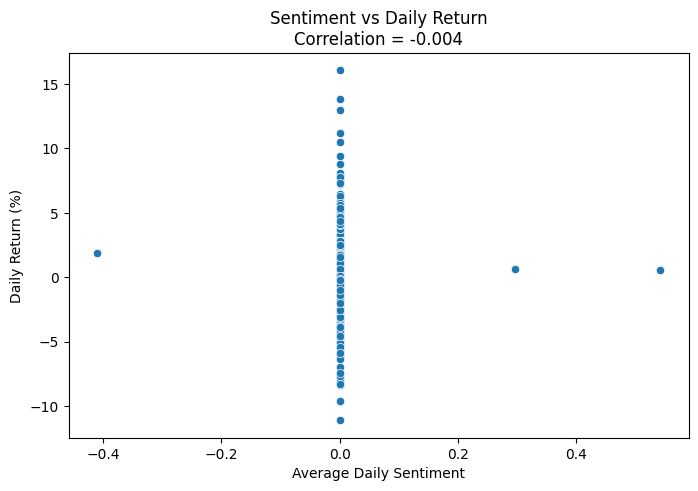

In [13]:
#scatter plot 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=merged_df['sentiment'],
    y=merged_df['daily_return']
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.3f}")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.show()

In [14]:
# sentimetn classification
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
merged_df['sentiment_category'] = merged_df['sentiment'].apply(classify_sentiment)

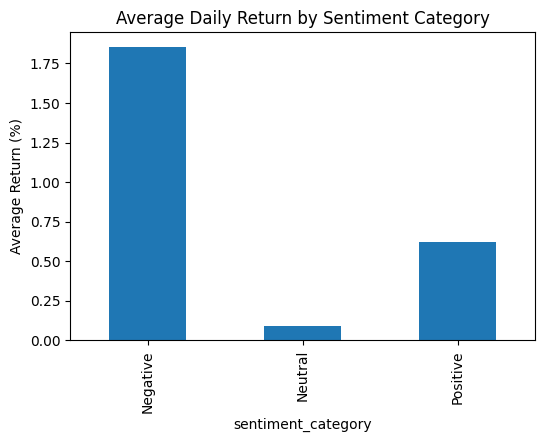

In [15]:
#barchart
avg_returns = (
    merged_df
    .groupby('sentiment_category')['daily_return']
    .mean()
)

plt.figure(figsize=(6,4))

avg_returns.plot(kind='bar')

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

The correlation coefficient for this stock was approximately -0.004, indicating virtually no linear relationship between average daily news sentiment and stock returns. The negative sign suggests a slight inverse relationship; however, the magnitude is too small to indicate meaningful predictive power. This reinforces the idea that stock prices are influenced by many external financial and economic factors beyond headline sentiment alone

In [16]:
print(merged_df.shape)
print(merged_df[['sentiment','daily_return']].corr())
print(merged_df.head())

(3773, 4)
              sentiment  daily_return
sentiment      1.000000     -0.003734
daily_return  -0.003734      1.000000
    date_only  daily_return  sentiment sentiment_category
1  2009-01-05      2.094467        0.0            Neutral
2  2009-01-06      1.832057        0.0            Neutral
3  2009-01-07     -3.607137        0.0            Neutral
4  2009-01-08      0.987523        0.0            Neutral
5  2009-01-09     -3.112007        0.0            Neutral
